In [ ]:
#NAME: Shaza Adelina
#ID:SN0107857
#LAB10

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


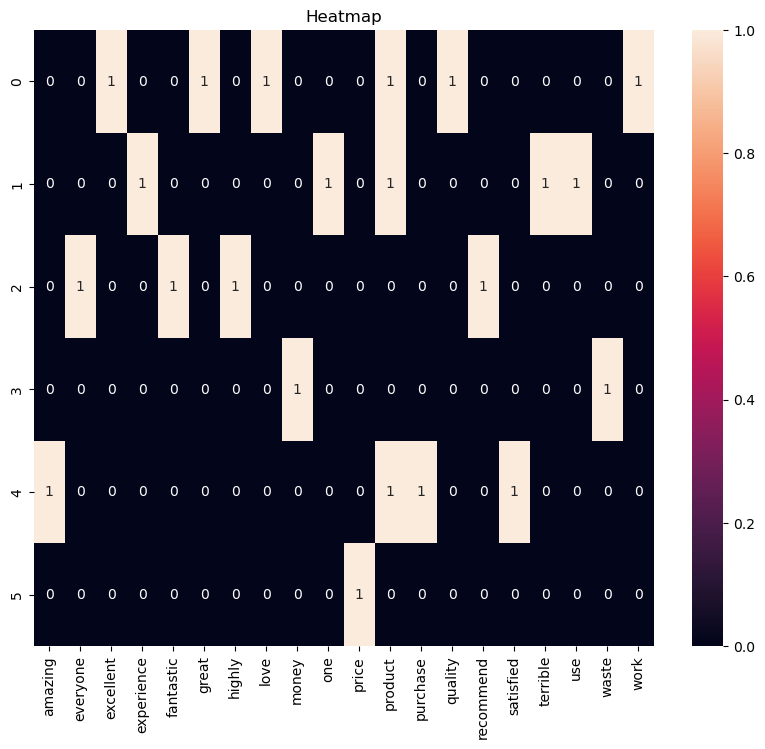

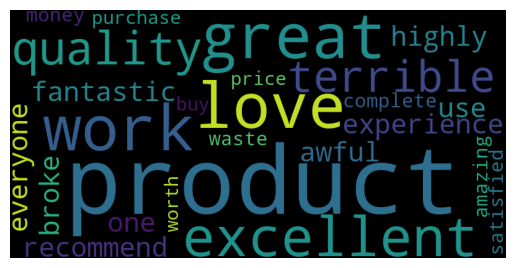

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

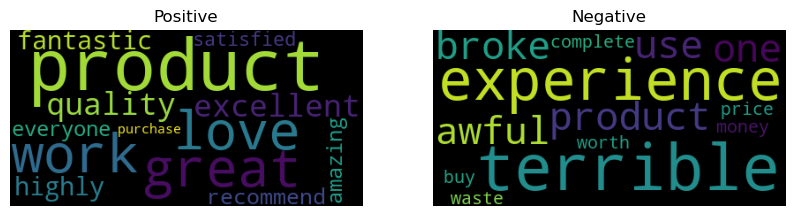

In [8]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

# download nltk data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# load dataset
df = pd.read_csv('simple_dataset.csv')

# initialize lemmatizer
lemmatizer = WordNetLemmatizer()


def preprocess_review(review):
    review = str(review)  # avoid errors if NaN

    review = review.lower()
    review = re.sub(r'[^\w\s]', '', review)
    review = re.sub(r'\d+', '', review)

    tokens = word_tokenize(review)

    stop_words = set(stopwords.words('english'))
    tokens = [w for w in tokens if w not in stop_words]

    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return ' '.join(tokens)

# apply preprocessing
df['preprocessed_text'] = df['text'].apply(preprocess_review)

# vectorization
vectorizer = CountVectorizer(max_features=20)
X = vectorizer.fit_transform(df['preprocessed_text'])
term_freq_matrix = X.toarray()
terms = vectorizer.get_feature_names_out()

# heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(term_freq_matrix, xticklabels=terms, annot=True)
plt.title("Heatmap")
plt.show()

# wordcloud
all_text = " ".join(df['preprocessed_text'])
wc = WordCloud(width=800, height=400).generate(all_text)

plt.imshow(wc)
plt.axis('off')
plt.show()

# sentiment wordcloud
pos_text = " ".join(df[df['category'] == 'Positive']['preprocessed_text'])
neg_text = " ".join(df[df['category'] == 'Negative']['preprocessed_text'])

wc_pos = WordCloud().generate(pos_text)
wc_neg = WordCloud().generate(neg_text)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(wc_pos)
plt.title("Positive")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(wc_neg)
plt.title("Negative")
plt.axis('off')
